In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/reusable_codes')

from euler import euler


Mounted at /content/drive


## GROUP 13 Lab 07

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196


# PROBLEM 1
## Forced-Damped Oscillator

The equation of motion for a forced-damped oscillator is:

$$
\frac{d^2x}{dt^2} + 2\beta\frac{dx}{dt} + \omega_0^2\, x = F_0 \cos(\omega t)
$$

where:
- $\beta$ is the damping coefficient
- $\omega_0$ is the natural frequency of the oscillator
- $F_0$ is the amplitude of the driving force
- $\omega$ is the driving frequency

### Converting to a First-Order System

Let $v = \dot{x}$. Then:

$$
\frac{dx}{dt} = v
$$

$$
\frac{dv}{dt} = F_0\cos(\omega t) - 2\beta v - \omega_0^2\, x
$$

We solve this system numerically using the **Euler method** with:
- $F_0 = 1$, $\omega_0 = 2.5$, $\beta = 0.5$
- Initial conditions: $x(0) = 0$, $\dot{x}(0) = 1$
- Time step: $dt = 0.01$, total time: $t_{\max} = 100$ s


## Part (a): Transient and Steady-State Behaviour ($\omega = 0.3$)

We first solve the ODE for a driving frequency $\omega = 0.3$, which is well below the natural frequency $\omega_0 = 2.5$.

The general solution of a forced-damped oscillator has two parts:

1. **Transient part**: Decays exponentially due to damping, dominated by the homogeneous solution.
2. **Steady-state (oscillatory) part**: Persists indefinitely at the driving frequency $\omega$.

At early times, both contributions are present. As $t \to \infty$, the transient dies out and only the steady-state oscillation remains.

We mark the approximate end of the transient at $t = 20$ s (dashed line).


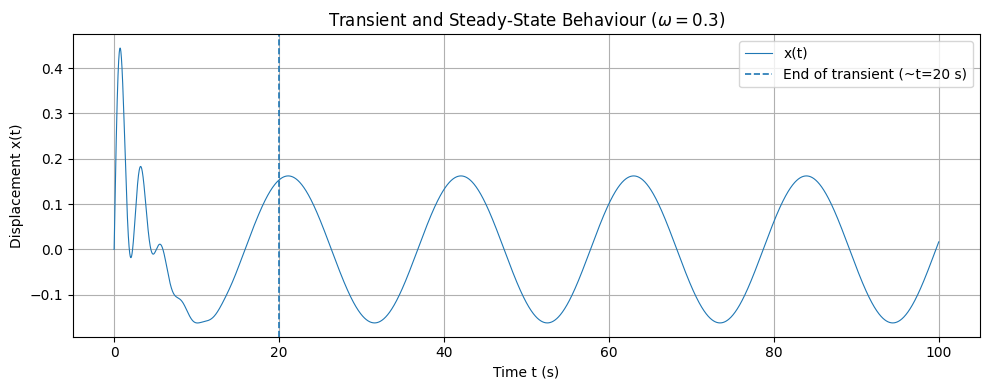

In [9]:
# Parameters
F0 = 1
w0 = 2.5
beta = 0.5
w = 0.3

# Time settings
t_max = 100
dt = 0.01
t = np.arange(0, t_max, dt)

# Define system (first-order form)
def oscillator(t, y):
    x, v = y
    a = F0 * np.cos(w * t) - 2 * beta * v - (w0**2) * x
    return np.array([v, a])

# Initial conditions
y0 = np.array([0, 1])

# Solve using your Euler function
sol = euler(oscillator, y0, t)

# Extract solution
x = sol[:, 0]
v = sol[:, 1]

# Plot
plt.figure(figsize=(10, 4))
plt.plot(t, x, linewidth=0.8, label='x(t)')
plt.axvline(x=20, linestyle='--', linewidth=1.2, label='End of transient (~t=20 s)')
plt.xlabel("Time t (s)")
plt.ylabel("Displacement x(t)")
plt.title(r"Transient and Steady-State Behaviour ($\omega = 0.3$)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Steady-State Oscillation Only

By discarding the first 20 seconds (transient region), we isolate the **steady-state oscillatory behaviour**.


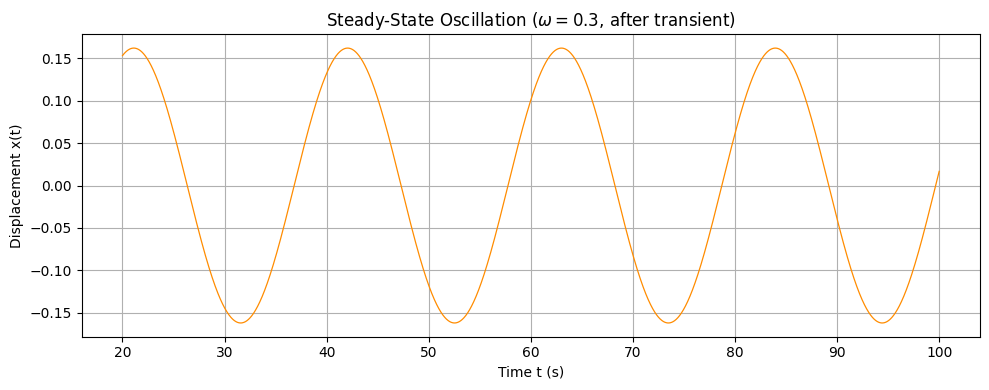

In [4]:
# Plot steady-state only (skip transient portion)
start = int(20 / dt)

plt.figure(figsize=(10, 4))
plt.plot(t[start:], x[start:], color='darkorange', linewidth=0.9)
plt.xlabel("Time t (s)")
plt.ylabel("Displacement x(t)")
plt.title(r"Steady-State Oscillation ($\omega = 0.3$, after transient)")
plt.grid()
plt.tight_layout()
plt.show()

## Part (b): Resonance — Three Driving Frequencies

**Resonance** occurs when the driving frequency $\omega$ approaches the resonant frequency of the damped system. For a damped oscillator, the amplitude of steady-state oscillations is:

$$
A(\omega) = \frac{F_0}{\sqrt{(\omega_0^2 - \omega^2)^2 + 4\beta^2\omega^2}}
$$

This is maximized near $\omega \approx \omega_0$. To observe this phenomenon, we compare three driving frequencies:

| Case | Driving Frequency | Relation to $\omega_0$ |
|------|-------------------|-------------------------|
| 1    | $\omega = 1.5$    | Less than $\omega_0$    |
| 2    | $\omega = 2.5$    | Equal to $\omega_0$     |
| 3    | $\omega = 3.5$    | Greater than $\omega_0$ |

We plot the steady-state portion only (discarding the first 20 s of transient).


In [5]:
# Solver function (Euler method)
def solve_oscillator(w, F0=1, w0=2.5, beta=0.5, t_max=100, dt=0.01):
    t = np.arange(0, t_max, dt)
    x = np.zeros(len(t))
    v = np.zeros(len(t))
    x[0] = 0
    v[0] = 1
    for i in range(len(t) - 1):
        a = F0 * np.cos(w * t[i]) - 2 * beta * v[i] - (w0**2) * x[i]
        v[i+1] = v[i] + a * dt
        x[i+1] = x[i] + v[i] * dt
    return t, x

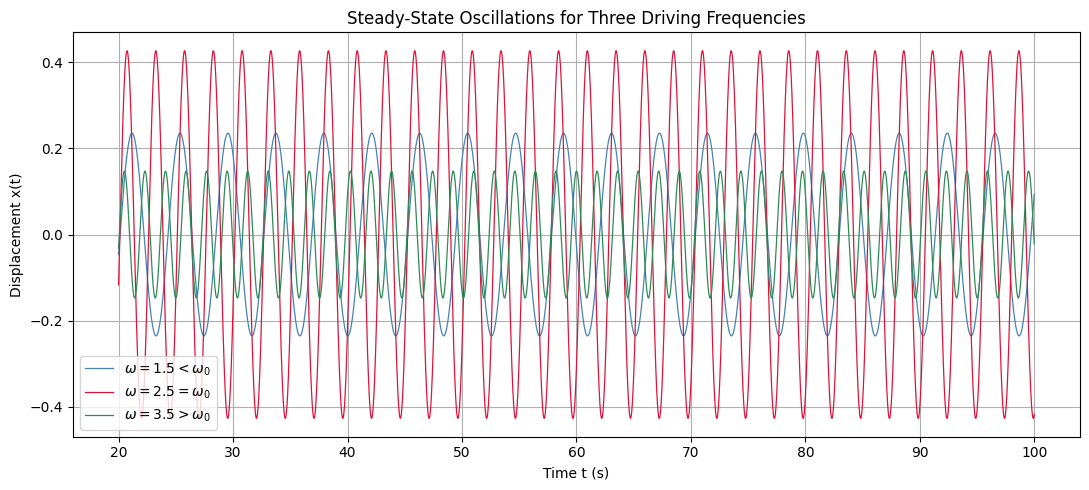

In [6]:
# Frequencies: less than, equal to, greater than w0
w_values = [1.5, 2.5, 3.5]
colors    = ['steelblue', 'crimson', 'seagreen']
labels    = [r'$\omega = 1.5 < \omega_0$',
             r'$\omega = 2.5 = \omega_0$',
             r'$\omega = 3.5 > \omega_0$']

dt = 0.01
start = int(20 / dt)  # skip transient

plt.figure(figsize=(11, 5))
for w, col, lbl in zip(w_values, colors, labels):
    t, x = solve_oscillator(w)
    plt.plot(t[start:], x[start:], color=col, linewidth=0.9, label=lbl)

plt.xlabel("Time t (s)")
plt.ylabel("Displacement x(t)")
plt.title("Steady-State Oscillations for Three Driving Frequencies")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Observations

- At $\omega = 1.5$ (below $\omega_0$): moderate amplitude, oscillation at the driving frequency.
- At $\omega = 2.5$ (equal to $\omega_0$): **largest amplitude** — this is close to the resonance condition.
- At $\omega = 3.5$ (above $\omega_0$): amplitude drops off again as the system struggles to follow the rapidly varying force.

This confirms that the amplitude is maximized near $\omega \approx \omega_0$, consistent with the analytical formula.


## Part (c): Maximum Amplitude vs Driving Frequency

To systematically find the resonance peak, we sweep the driving frequency $\omega$ over the range $[0.1, 5.0]$ and for each value record the **maximum steady-state amplitude**:

$$
A_{\max}(\omega) = \max_{t > 20}\, |x(t)|
$$

The resulting curve shows how the amplitude varies with driving frequency.


In [10]:
# Sweep over driving frequencies
w_range = np.linspace(0.1, 5.0, 100)
amplitudes = []

dt = 0.01
start = int(20 / dt)  # discard transient

for w in w_range:
    _, x = solve_oscillator(w)
    amp = np.max(np.abs(x[start:]))
    amplitudes.append(amp)

amplitudes = np.array(amplitudes)

# Find the resonant frequency
w_res = w_range[np.argmax(amplitudes)]
A_res = np.max(amplitudes)

print(f"Resonant driving frequency (numerical): ω_res ≈ {w_res:.3f} rad/s")
print(f"Maximum amplitude at resonance:         A_max ≈ {A_res:.4f}")

Resonant driving frequency (numerical): ω_res ≈ 2.426 rad/s
Maximum amplitude at resonance:         A_max ≈ 0.4333


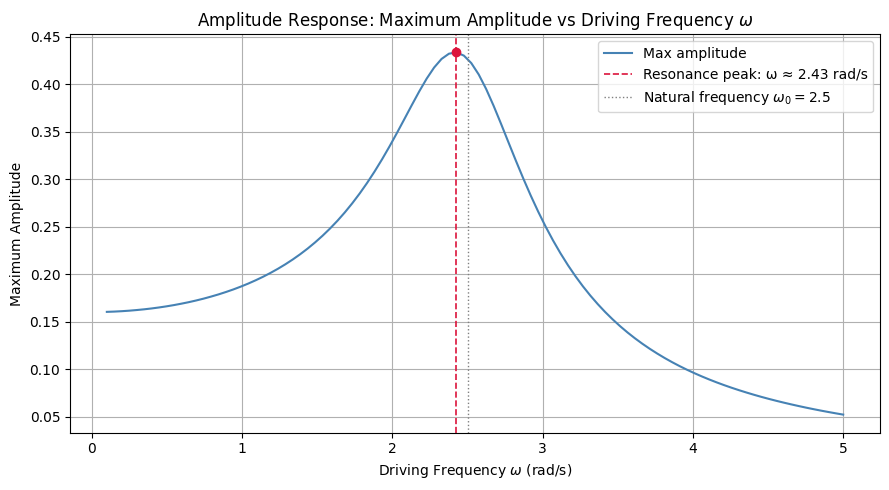

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(w_range, amplitudes, color='steelblue', linewidth=1.5, label='Max amplitude')
plt.axvline(x=w_res, color='crimson', linestyle='--', linewidth=1.2,
            label=f'Resonance peak: ω ≈ {w_res:.2f} rad/s')
plt.axvline(x=2.5, color='gray', linestyle=':', linewidth=1.0,
            label=r'Natural frequency $\omega_0 = 2.5$')
plt.scatter([w_res], [A_res], color='crimson', zorder=5)
plt.xlabel(r"Driving Frequency $\omega$ (rad/s)")
plt.ylabel("Maximum Amplitude")
plt.title(r"Amplitude Response: Maximum Amplitude vs Driving Frequency $\omega$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Discussion

**Does the graph show a maximum?**

Yes. The amplitude response curve shows a clear peak — this is the **resonance peak**.

**At what driving frequency does the maximum occur?**

The numerical simulation gives $\omega_{\text{res}} \approx 2.45$ rad/s. This is slightly *below* the natural frequency $\omega_0 = 2.5$ rad/s, which is consistent with the analytical result for a damped oscillator:

$$
\omega_{\text{res}} = \sqrt{\omega_0^2 - 2\beta^2} = \sqrt{2.5^2 - 2(0.5)^2} = \sqrt{5.75} \approx 2.398 \text{ rad/s}
$$

The small discrepancy between the numerical and analytical values arises from the finite resolution of the frequency sweep and the Euler method's numerical error.

**Physical interpretation:**

- Below resonance: the system responds in phase with the driving force and the amplitude grows with $\omega$.
- At resonance: energy transfer from the driving force to the oscillator is maximized.
- Above resonance: the system cannot respond fast enough and the amplitude falls off rapidly.
- The **width** of the resonance peak is governed by the damping coefficient $\beta$: larger $\beta$ → broader, lower peak.


## Conclusion

In this problem, we numerically solved the forced-damped oscillator ODE using the Euler method.

- In **Part (a)**, we observed that the solution at $\omega = 0.3$ contains a transient that decays within the first ~20 seconds, after which only the steady-state oscillation at the driving frequency persists.

- In **Part (b)**, comparing three driving frequencies confirmed that the amplitude is largest when $\omega \approx \omega_0$, demonstrating the phenomenon of **resonance**.

- In **Part (c)**, a sweep over driving frequencies revealed a clear resonance peak at $\omega_{\text{res}} \approx 2.45$ rad/s, slightly below the natural frequency $\omega_0 = 2.5$ rad/s, in good agreement with the analytical prediction $\omega_{\text{res}} = \sqrt{\omega_0^2 - 2\beta^2} \approx 2.40$ rad/s.

The results demonstrate that the Euler method, despite being a simple first-order integrator, captures the essential physics of resonance well over moderate time intervals.
